In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time


In [2]:
def rosenbrock(x):
    a = 1
    b = 100

    x1, x2 = x

    return (a - x1)**2 + b * (x2 - x1**2)**2


In [3]:
def rosenbrock_gradient(x):
    x1, x2 = x

    dx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1**2)
    dx2 = 200 * (x2 - x1**2)

    return np.array([dx1, dx2])


In [4]:
def gradient_descent(
    function,
    gradient,
    x0,
    learning_rate,
    max_iterations=10000
):

    x = np.array(x0, dtype=float)

    history = []

    start_time = time.time()

    for i in range(max_iterations):

        # Calculate function value
        f_value = function(x)

        # Store function value
        history.append(f_value)

        # Calculate gradient
        grad = gradient(x)

        # Update x
        x = x - learning_rate * grad

        # Stop if gradient is very small
        if np.linalg.norm(grad) < 1e-8:
            break

        # Stop if values become too large
        if not np.all(np.isfinite(x)):
            break

    end_time = time.time()

    return x, function(x), history, end_time - start_time


In [8]:
learning_rates = [0.01, 0.05, 0.1,0.0001,0.005,0.0005]

initial_point = [1.2, 0.5]

for lr in learning_rates:

    x_opt, f_opt, history, elapsed_time = gradient_descent(
        rosenbrock,
        rosenbrock_gradient,
        initial_point,
        lr
    )

    print("\nLearning Rate:", lr)
    print("Optimal x:", x_opt)
    print("Final f(x):", f_opt)
    print("Iterations:", len(history))
    print("Time:", elapsed_time, "seconds")
    print(history)
   # m=history
   # n=list(range(1,10001))
   # plt.plot(n, m, color='blue', marker='o', linestyle='-', label='Trend Line')
   # plt.show()

/tmp/ipykernel_2853/51260158.py:7: RuntimeWarning: overflow encountered in scalar power
  return (a - x1)**2 + b * (x2 - x1**2)**2
/tmp/ipykernel_2853/2924737305.py:4: RuntimeWarning: overflow encountered in scalar power
  dx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1**2)
/tmp/ipykernel_2853/2924737305.py:5: RuntimeWarning: overflow encountered in scalar power
  dx2 = 200 * (x2 - x1**2)
/tmp/ipykernel_2853/51260158.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  return (a - x1)**2 + b * (x2 - x1**2)**2



Learning Rate: 0.01
Optimal x: [-inf  inf]
Final f(x): nan
Iterations: 7
Time: 0.011284112930297852 seconds
[np.float64(88.4), np.float64(7441.925317273596), np.float64(15160320566.993776), np.float64(8.947709855568324e+28), np.float64(1.833899975954493e+85), np.float64(1.5789446271002197e+254), np.float64(inf)]

Learning Rate: 0.05
Optimal x: [inf inf]
Final f(x): nan
Iterations: 6
Time: 0.0023725032806396484 seconds
[np.float64(88.4), np.float64(19999678.402335994), np.float64(1.3365987393695697e+23), np.float64(3.8205266256064135e+70), np.float64(8.922564059663497e+212), np.float64(inf)]

Learning Rate: 0.1
Optimal x: [inf inf]
Final f(x): nan
Iterations: 6
Time: 0.00026726722717285156 seconds
[np.float64(88.4), np.float64(366028404.85945576), np.float64(1.280788507650546e+28), np.float64(5.378636992017333e+86), np.float64(3.983425219518724e+262), np.float64(inf)]

Learning Rate: 0.0001
Optimal x: [0.89533473 0.80117847]
Final f(x): 0.010974693175361691
Iterations: 10000
Time: 1.06

# SGD with **Momentum**

In [9]:
def sgd_momentum(
    function,
    gradient,
    x0,
    learning_rate,
    momentum=0.9,
    max_iterations=10000
):

    x = np.array(x0, dtype=float)

    velocity = np.zeros_like(x)

    history = []

    start_time = time.time()

    for i in range(max_iterations):

        # Function value
        f_value = function(x)

        history.append(f_value)

        # Gradient
        grad = gradient(x)

        # Momentum update
        velocity = momentum * velocity + grad

        # Update parameters
        x = x - learning_rate * velocity

        # Convergence
        if np.linalg.norm(grad) < 1e-8:
            break

        # Divergence protection
        if not np.all(np.isfinite(x)):
            break

    end_time = time.time()

    return (
        x,
        function(x),
        history,
        end_time - start_time
    )


Run it on Rosenbrock

In [11]:
for lr in [ 0.01, 0.05, 0.001,0.1,0.005,0.0005]:

    x_opt, f_opt, history, elapsed_time = sgd_momentum(
        rosenbrock,
        rosenbrock_gradient,
        [-0.5, 1.5],
        lr
    )

    print("\nLearning Rate:", lr)
    print("Optimal x:", x_opt)
    print("Final f(x):", f_opt)
    print("Iterations:", len(history))
    print("Time:", elapsed_time)
    print(history)

/tmp/ipykernel_2853/51260158.py:7: RuntimeWarning: overflow encountered in scalar power
  return (a - x1)**2 + b * (x2 - x1**2)**2
/tmp/ipykernel_2853/2924737305.py:4: RuntimeWarning: overflow encountered in scalar power
  dx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1**2)
/tmp/ipykernel_2853/2924737305.py:5: RuntimeWarning: overflow encountered in scalar power
  dx2 = 200 * (x2 - x1**2)
/tmp/ipykernel_2853/51260158.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  return (a - x1)**2 + b * (x2 - x1**2)**2
/tmp/ipykernel_2853/2924737305.py:4: RuntimeWarning: overflow encountered in scalar multiply
  dx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1**2)



Learning Rate: 0.01
Optimal x: [-inf  inf]
Final f(x): nan
Iterations: 7
Time: 0.0027196407318115234
[np.float64(158.5), np.float64(9660.768581000002), np.float64(15447891935.90929), np.float64(9.460734201950252e+28), np.float64(2.167776428520617e+85), np.float64(2.607854962940613e+254), np.float64(inf)]

Learning Rate: 0.05
Optimal x: [           inf 1.6805881e+286]
Final f(x): inf
Iterations: 6
Time: 0.000331878662109375
[np.float64(158.5), np.float64(3102105.3231250006), np.float64(4.189134475957942e+20), np.float64(1.1762337222829765e+63), np.float64(2.6037594650523725e+190), np.float64(inf)]

Learning Rate: 0.001
Optimal x: [0.99999999 0.99999998]
Final f(x): 1.2321894951995156e-16
Iterations: 4161
Time: 0.11783409118652344
[np.float64(158.5), np.float64(50.937163408100005), np.float64(28.566245722742526), np.float64(124.42428513414386), np.float64(4.4579827175001805), np.float64(28.023412297421206), np.float64(38.27896479997297), np.float64(18.322576048575492), np.float64(0.5546

/tmp/ipykernel_2853/51260158.py:7: RuntimeWarning: overflow encountered in scalar power
  return (a - x1)**2 + b * (x2 - x1**2)**2
/tmp/ipykernel_2853/2924737305.py:4: RuntimeWarning: overflow encountered in scalar power
  dx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1**2)
/tmp/ipykernel_2853/2924737305.py:5: RuntimeWarning: overflow encountered in scalar power
  dx2 = 200 * (x2 - x1**2)
/tmp/ipykernel_2853/51260158.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  return (a - x1)**2 + b * (x2 - x1**2)**2
/tmp/ipykernel_2853/2924737305.py:4: RuntimeWarning: overflow encountered in scalar multiply
  dx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1**2)


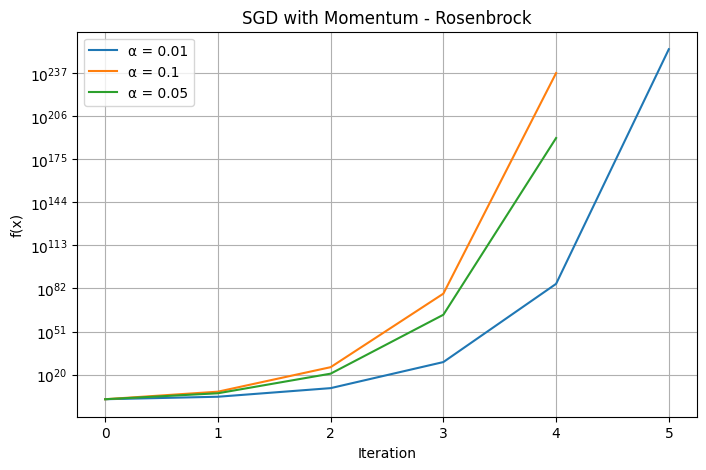

In [13]:
plt.figure(figsize=(8, 5))

for lr in [ 0.01,0.1,0.05]:

    x_opt, f_opt, history, elapsed_time = sgd_momentum(
        rosenbrock,
        rosenbrock_gradient,
        [-0.5, 1.5],
        lr
    )

    plt.semilogy(
        np.maximum(history, 1e-16),
        label=f"α = {lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title("SGD with Momentum - Rosenbrock")
plt.legend()
plt.grid(True)

plt.show()


# **Adam**

In [14]:
def adam(
    function,
    gradient,
    x0,
    learning_rate,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    max_iterations=10000
):

    x = np.array(x0, dtype=float)

    m = np.zeros_like(x)
    v = np.zeros_like(x)

    history = []

    start_time = time.time()

    for t in range(1, max_iterations + 1):

        # Function value
        f_value = function(x)

        history.append(f_value)

        # Gradient
        grad = gradient(x)

        # First moment
        m = beta1 * m + (1 - beta1) * grad

        # Second moment
        v = beta2 * v + (1 - beta2) * (grad ** 2)

        # Bias correction
        m_hat = m / (1 - beta1 ** t)

        v_hat = v / (1 - beta2 ** t)

        # Parameter update
        x = (
            x
            - learning_rate
            * m_hat
            / (np.sqrt(v_hat) + epsilon)
        )

        # Convergence
        if np.linalg.norm(grad) < 1e-8:
            break

        if not np.all(np.isfinite(x)):
            break

    end_time = time.time()

    return (
        x,
        function(x),
        history,
        end_time - start_time
    )


In [15]:
for lr in [0.01, 0.05, 0.1]:

    x_opt, f_opt, history, elapsed_time = adam(
        rosenbrock,
        rosenbrock_gradient,
        [-0.5, 1.5],
        lr
    )

    print("\nLearning Rate:", lr)
    print("Optimal x:", x_opt)
    print("Final f(x):", f_opt)
    print("Iterations:", len(history))
    print("Time:", elapsed_time)
    print(history)


Learning Rate: 0.01
Optimal x: [0.99999999 0.99999998]
Final f(x): 1.2108894536940508e-16
Iterations: 8765
Time: 0.3037395477294922
[np.float64(158.5), np.float64(153.54550100019875), np.float64(148.62449124196303), np.float64(143.74002921394123), np.float64(138.89522659385287), np.float64(134.093246027859), np.float64(129.33729812046337), np.float64(124.63063761496792), np.float64(119.97655874697593), np.float64(115.37838975614576), np.float64(110.83948654437617), np.float64(106.36322547186275), np.float64(101.95299528603354), np.float64(97.6121881822897), np.float64(93.34418999978618), np.float64(89.15236956025505), np.float64(85.04006716315297), np.float64(81.01058225628843), np.float64(77.06716030762696), np.float64(73.21297891126909), np.float64(69.45113316872897), np.float64(65.78462039569195), np.float64(62.216324214473), np.float64(58.74899810349308), np.float64(55.385248487281316), np.float64(52.127517463816076), np.float64(48.9780652804191), np.float64(45.93895268485591), np

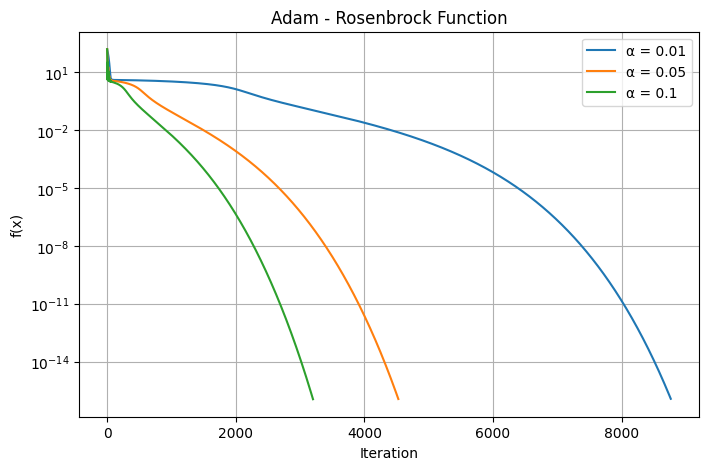

In [16]:
plt.figure(figsize=(8, 5))

for lr in [0.01, 0.05, 0.1]:

    x_opt, f_opt, history, elapsed_time = adam(
        rosenbrock,
        rosenbrock_gradient,
        [-0.5, 1.5],
        lr
    )

    plt.semilogy(
        np.maximum(history, 1e-16),
        label=f"α = {lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title("Adam - Rosenbrock Function")
plt.legend()
plt.grid(True)

plt.show()


# **RMSprop**

In [17]:
def rmsprop(
    function,
    gradient,
    x0,
    learning_rate,
    beta=0.9,
    epsilon=1e-8,
    max_iterations=10000
):

    x = np.array(x0, dtype=float)

    squared_gradient = np.zeros_like(x)

    history = []

    start_time = time.time()

    for i in range(max_iterations):

        # Function value
        f_value = function(x)

        history.append(f_value)

        # Gradient
        grad = gradient(x)

        # Moving average of squared gradient
        squared_gradient = (
            beta * squared_gradient
            + (1 - beta) * grad**2
        )

        # Update
        x = (
            x
            - learning_rate
            * grad
            / (np.sqrt(squared_gradient) + epsilon)
        )

        # Convergence
        if np.linalg.norm(grad) < 1e-8:
            break

        if not np.all(np.isfinite(x)):
            break

    end_time = time.time()

    return (
        x,
        function(x),
        history,
        end_time - start_time
    )


In [18]:
for lr in [0.01, 0.05, 0.1]:

    x_opt, f_opt, history, elapsed_time = rmsprop(
        rosenbrock,
        rosenbrock_gradient,
        [-0.5, 1.5],
        lr
    )

    print("\nLearning Rate:", lr)
    print("Optimal x:", x_opt)
    print("Final f(x):", f_opt)
    print("Iterations:", len(history))
    print("Time:", elapsed_time)
    print(history)


Learning Rate: 0.01
Optimal x: [0.98014385 0.97553339]
Final f(x): 0.022450744804705443
Iterations: 10000
Time: 0.2583789825439453
[np.float64(158.5), np.float64(142.94722914156085), np.float64(132.00665471338363), np.float64(123.08576404443288), np.float64(115.36424938937205), np.float64(108.4624434572585), np.float64(102.1694773337174), np.float64(96.35476548356085), np.float64(90.93136106146262), np.float64(85.83830763059964), np.float64(81.03119510841432), np.float64(76.4766952807253), np.float64(72.14920270802334), np.float64(68.02866739415462), np.float64(64.09913967035342), np.float64(60.347760110629316), np.float64(56.76403809366355), np.float64(53.33932360449731), np.float64(50.066411974850205), np.float64(46.939242266286186), np.float64(43.95266299642001), np.float64(41.102247188089095), np.float64(38.38414413512378), np.float64(35.79495890124782), np.float64(33.33165304459618), np.float64(30.99146178539393), np.float64(28.771824058087255), np.float64(26.670322772454732), np

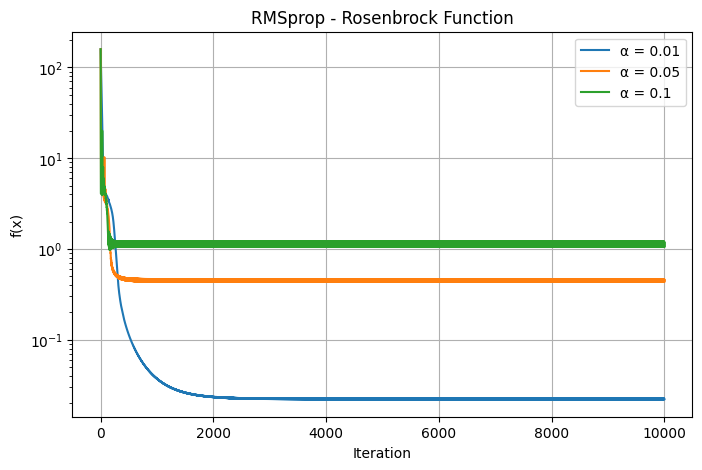

In [19]:
plt.figure(figsize=(8, 5))

for lr in [0.01, 0.05, 0.1]:

    x_opt, f_opt, history, elapsed_time = rmsprop(
        rosenbrock,
        rosenbrock_gradient,
        [-0.5, 1.5],
        lr
    )

    plt.semilogy(
        np.maximum(history, 1e-16),
        label=f"α = {lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title("RMSprop - Rosenbrock Function")
plt.legend()
plt.grid(True)

plt.show()


# **Adagrad**

In [22]:
def adagrad(
    function,
    gradient,
    x0,
    learning_rate,
    epsilon=1e-8,
    max_iterations=10000
):

    x = np.array(x0, dtype=float)

    accumulated_gradient = np.zeros_like(x)

    history = []

    start_time = time.time()

    for i in range(max_iterations):

        # Function value
        f_value = function(x)

        history.append(f_value)

        # Gradient
        grad = gradient(x)

        # Accumulate squared gradients
        accumulated_gradient += grad**2

        # Update
        x = (
            x
            - learning_rate
            * grad
            / (
                np.sqrt(accumulated_gradient)
                + epsilon
            )
        )

        # Convergence
        if np.linalg.norm(grad) < 1e-8:
            break

        if not np.all(np.isfinite(x)):
            break

    end_time = time.time()

    return (
        x,
        function(x),
        history,
        end_time - start_time
    )


In [23]:
for lr in [0.01, 0.05, 0.1]:

    x_opt, f_opt, history, elapsed_time = adagrad(
        rosenbrock,
        rosenbrock_gradient,
        [-0.5, 1.5],
        lr
    )

    print("\nLearning Rate:", lr)
    print("Optimal x:", x_opt)
    print("Final f(x):", f_opt)
    print("Iterations:", len(history))
    print("Time:", elapsed_time)
    print(history)


Learning Rate: 0.01
Optimal x: [-1.00104993  1.00944394]
Final f(x): 4.009592760226259
Iterations: 10000
Time: 0.37450218200683594
[np.float64(158.5), np.float64(153.54550100019875), np.float64(150.07255299466425), np.float64(147.25529244634504), np.float64(144.8290006849283), np.float64(142.66969823251398), np.float64(140.70764946828328), np.float64(138.8990551757717), np.float64(137.21428538263245), np.float64(135.63219218330113), np.float64(134.13705689127266), np.float64(132.71681878964026), np.float64(131.36198380378798), np.float64(130.064919078395), np.float64(128.81937878062635), np.float64(127.62017476011286), np.float64(126.4629414061169), np.float64(125.34396373239035), np.float64(124.26004907682264), np.float64(123.20842961032677), np.float64(122.18668706836192), np.float64(121.19269381077595), np.float64(120.22456607861365), np.float64(119.28062649777412), np.float64(118.35937368730917), np.float64(117.45945739306548), np.float64(116.5796579662219), np.float64(115.7188692

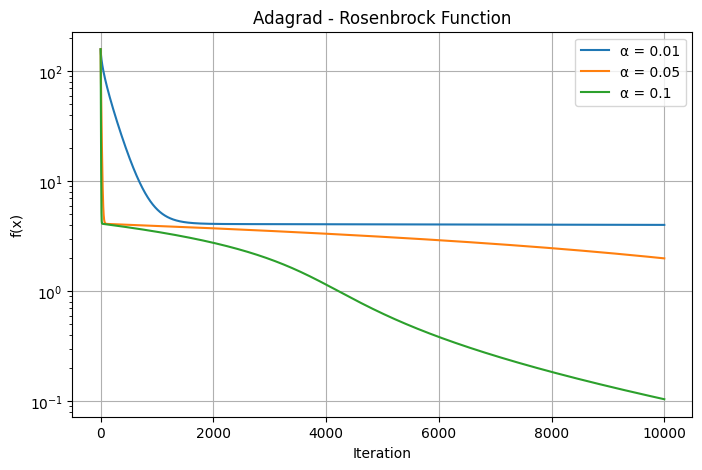

In [24]:
plt.figure(figsize=(8, 5))

for lr in [0.01, 0.05, 0.1]:

    x_opt, f_opt, history, elapsed_time = adagrad(
        rosenbrock,
        rosenbrock_gradient,
        [-0.5, 1.5],
        lr
    )

    plt.semilogy(
        np.maximum(history, 1e-16),
        label=f"α = {lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title("Adagrad - Rosenbrock Function")
plt.legend()
plt.grid(True)

plt.show()


# One comparison graph for all 5 **algorithms**

In [30]:
algorithms = {

    "Adam": adam,
    "RMSprop": rmsprop,
    "Adagrad": adagrad
}


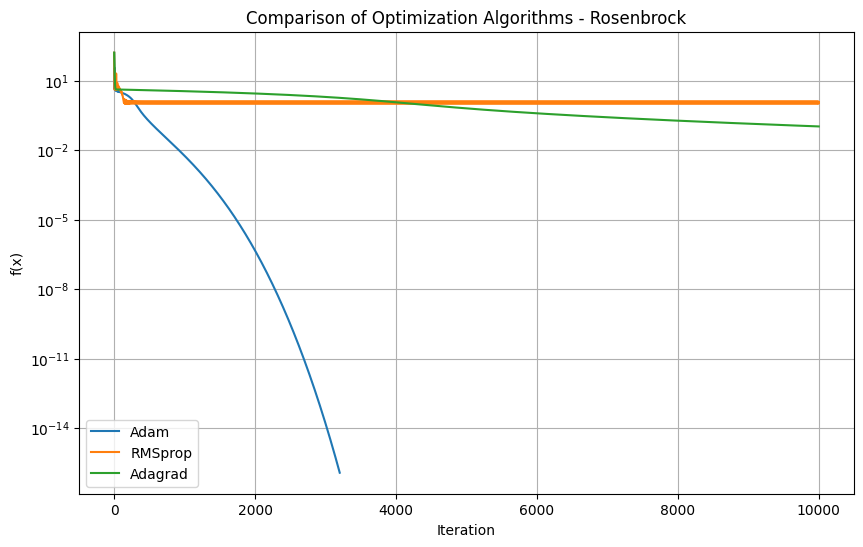

In [68]:
learning_rate = 0.1

plt.figure(figsize=(10, 6))

for name, algorithm in algorithms.items():

    x_opt, f_opt, history, elapsed_time = algorithm(
        rosenbrock,
        rosenbrock_gradient,
        [-0.5, 1.5],
        learning_rate
    )

    plt.semilogy(
        np.maximum(history, 1e-16),
        label=name
    )

plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title(
    "Comparison of Optimization Algorithms - Rosenbrock"
)

plt.legend()
plt.grid(True)

plt.show()


# Comparison for all three learning rates

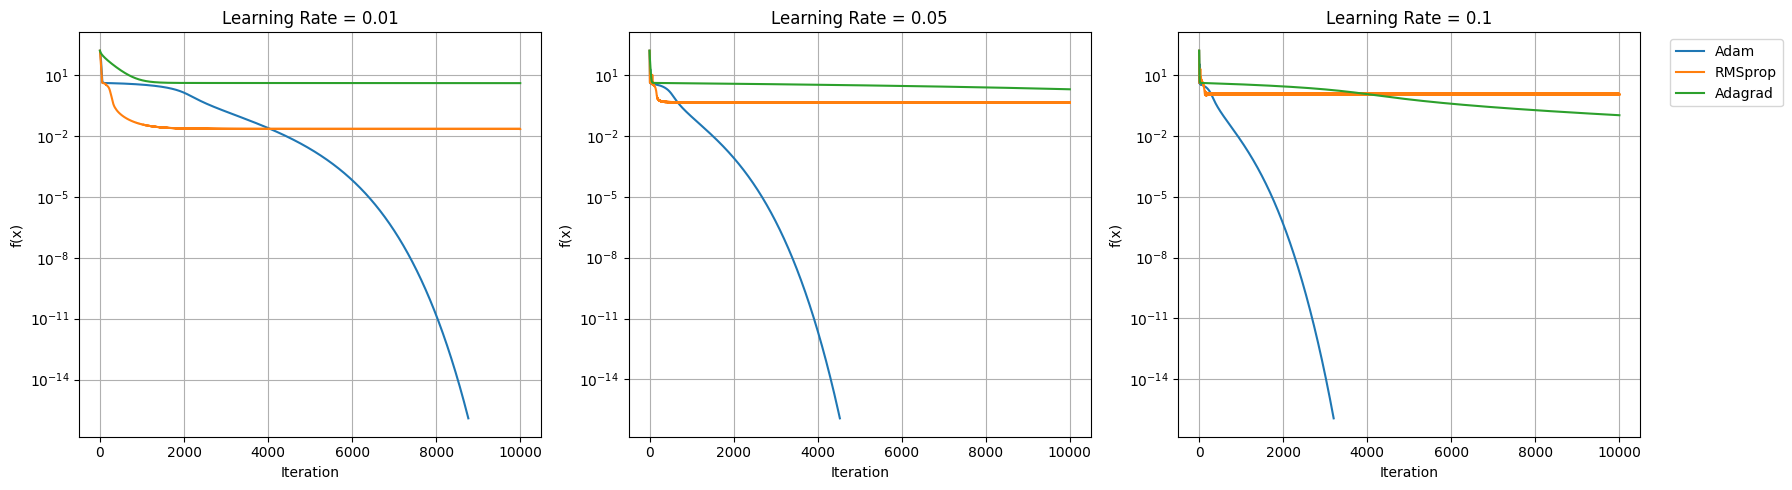

In [32]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, lr in zip(
    axes,
    [0.01, 0.05, 0.1]
):

    for name, algorithm in algorithms.items():

        x_opt, f_opt, history, elapsed_time = algorithm(
            rosenbrock,
            rosenbrock_gradient,
            [-0.5, 1.5],
            lr
        )

        ax.semilogy(
            np.maximum(history, 1e-16),
            label=name
        )

    ax.set_title(f"Learning Rate = {lr}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("f(x)")
    ax.grid(True)

axes[-1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# Ackley **Function**

In [33]:
def ackley(x):
    if x == 0:
        return 0.0

    return (
        -20 * np.exp(-0.2 * abs(x))
        - np.exp(np.cos(2 * np.pi * x))
        + 20
        + np.e
    )

In [34]:
def gradient(x):
    if x == 0:
        return 0.0

    term1 = 4 * np.sign(x) * np.exp(-0.2 * abs(x))

    term2 = (
        2 * np.pi
        * np.sin(2 * np.pi * x)
        * np.exp(np.cos(2 * np.pi * x))
    )

    return term1 + term2

# Gradient **Decent**

In [48]:
def gradient_descent(x0, alpha, max_iter=10000, tolerance=1e-8):

    x = x0
    history = []

    for i in range(max_iter):

        f = ackley(x)
        history.append(f)

        grad = gradient(x)

        if abs(grad) < tolerance:
            break

        x = x - alpha * grad

    return x, history, i + 1




Gradient Descent
Learning rate: 0.01
Final x      : 3.983067699680924
Final f(x)   : 10.998262102599448
Iterations   : 8
Time (sec)   : 0.0007529679987783311

Gradient Descent
Learning rate: 0.05
Final x      : 0.38757051153916794
Final f(x)   : 3.7426601953693894
Iterations   : 10000
Time (sec)   : 0.11727517699910095

Gradient Descent
Learning rate: 0.1
Final x      : -1.3866561396566341
Final f(x)   : 7.093118704709461
Iterations   : 10000
Time (sec)   : 0.11665915899902757


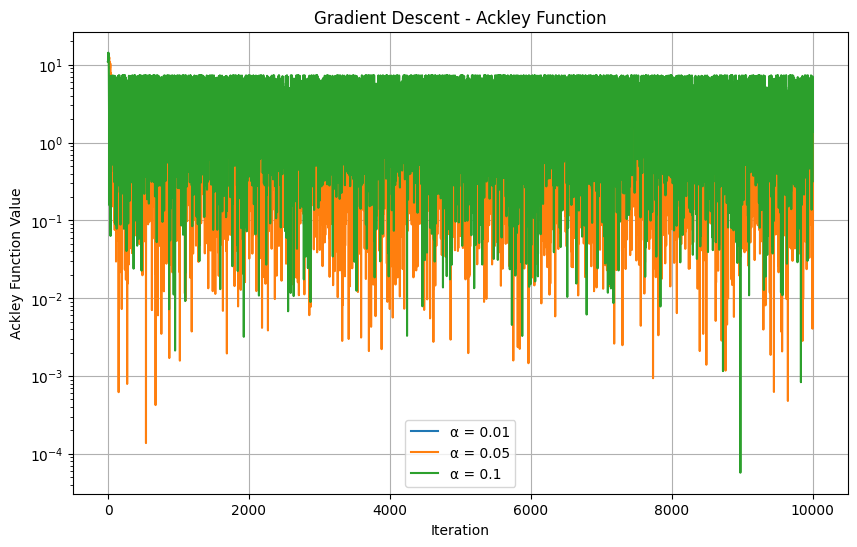

In [49]:
x0 = 4.0

learning_rates = [0.01, 0.05, 0.1]

plt.figure(figsize=(10, 6))

for alpha in learning_rates:

    start = time.perf_counter()

    x_final, history, iterations = gradient_descent(
        x0, alpha
    )

    end = time.perf_counter()

    print("\nGradient Descent")
    print("Learning rate:", alpha)
    print("Final x      :", x_final)
    print("Final f(x)   :", ackley(x_final))
    print("Iterations   :", iterations)
    print("Time (sec)   :", end - start)

    plt.plot(
        history,
        label=f"α = {alpha}"
    )


plt.xlabel("Iteration")
plt.ylabel("Ackley Function Value")
plt.title("Gradient Descent - Ackley Function")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

# SGD with momentum

In [52]:
def momentum(x0, alpha, beta=0.9,
             max_iter=10000, tolerance=1e-8):

    x = x0
    velocity = 0.0

    history = []

    for i in range(max_iter):

        f = ackley(x)
        history.append(f)

        grad = gradient(x)

        if abs(grad) < tolerance:
            break

        velocity = beta * velocity + grad

        x = x - alpha * velocity

    return x, history, i + 1



SGD with Momentum
Learning rate: 0.01
Final x      : 3.9830676996981613
Final f(x)   : 10.998262102599446
Iterations   : 318
Time (sec)   : 0.004882171999270213

SGD with Momentum
Learning rate: 0.05
Final x      : -97.11613899493638
Final f(x)   : 20.61108352458559
Iterations   : 10000
Time (sec)   : 0.14439763500013214

SGD with Momentum
Learning rate: 0.1
Final x      : -108.92774163381452
Final f(x)   : 20.26188770239447
Iterations   : 10000
Time (sec)   : 0.14694794999923033


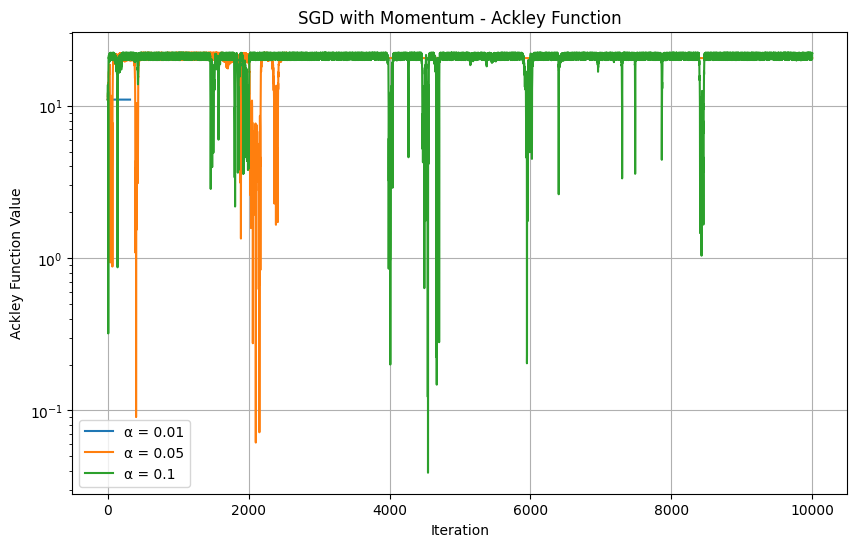

In [53]:
x0 = 4.0

learning_rates = [0.01, 0.05, 0.1]

plt.figure(figsize=(10, 6))

for alpha in learning_rates:

    start = time.perf_counter()

    x_final, history, iterations = momentum(
        x0, alpha
    )

    end = time.perf_counter()

    print("\nSGD with Momentum")
    print("Learning rate:", alpha)
    print("Final x      :", x_final)
    print("Final f(x)   :", ackley(x_final))
    print("Iterations   :", iterations)
    print("Time (sec)   :", end - start)

    plt.plot(
        history,
        label=f"α = {alpha}"
    )


plt.xlabel("Iteration")
plt.ylabel("Ackley Function Value")
plt.title("SGD with Momentum - Ackley Function")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

# Adam

In [54]:
def adam(x0, alpha,
         beta1=0.9,
         beta2=0.999,
         epsilon=1e-8,
         max_iter=10000,
         tolerance=1e-8):

    x = x0

    m = 0.0
    v = 0.0

    history = []

    for i in range(1, max_iter + 1):

        f = ackley(x)
        history.append(f)

        grad = gradient(x)

        if abs(grad) < tolerance:
            break

        # First moment
        m = beta1 * m + (1 - beta1) * grad

        # Second moment
        v = beta2 * v + (1 - beta2) * grad ** 2

        # Bias correction
        m_hat = m / (1 - beta1 ** i)
        v_hat = v / (1 - beta2 ** i)

        # Update
        x = x - alpha * m_hat / (
            np.sqrt(v_hat) + epsilon
        )

    return x, history, i


Adam
Learning rate: 0.001
Final x      : 3.98306769972254
Final f(x)   : 10.998262102599444
Iterations   : 291
Time (sec)   : 0.004508879999775672

Adam
Learning rate: 0.005
Final x      : 3.9830676997204932
Final f(x)   : 10.998262102599444
Iterations   : 316
Time (sec)   : 0.004221793000397156

Adam
Learning rate: 0.0001
Final x      : 3.9830676997845504
Final f(x)   : 10.998262102599444
Iterations   : 888
Time (sec)   : 0.01590160599880619


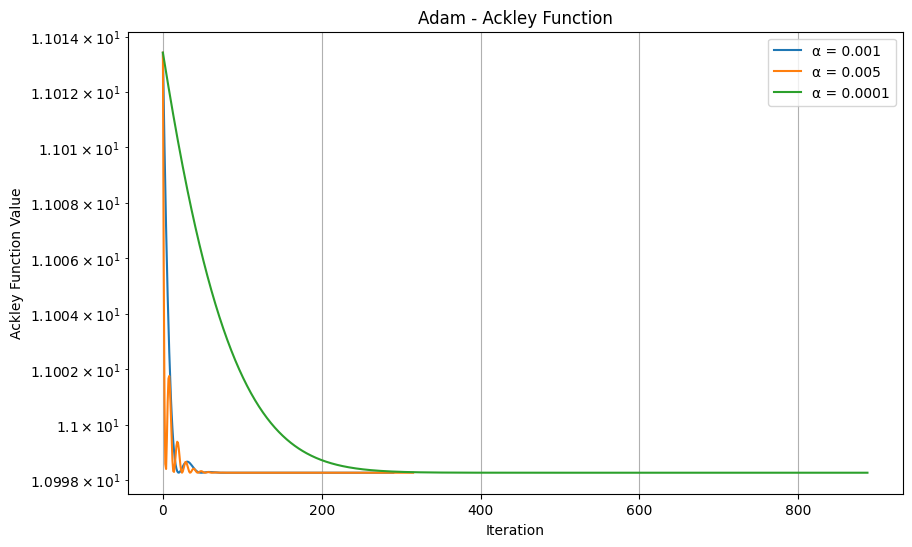

In [56]:
x0 = 4.0

learning_rates = [0.01, 0.05, 0.1]

plt.figure(figsize=(10, 6))

for alpha in learning_rates:

    start = time.perf_counter()

    x_final, history, iterations = adam(
        x0, alpha
    )

    end = time.perf_counter()

    print("\nAdam")
    print("Learning rate:", alpha)
    print("Final x      :", x_final)
    print("Final f(x)   :", ackley(x_final))
    print("Iterations   :", iterations)
    print("Time (sec)   :", end - start)

    plt.plot(
        history,
        label=f"α = {alpha}"
    )


plt.xlabel("Iteration")
plt.ylabel("Ackley Function Value")
plt.title("Adam - Ackley Function")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

# RMSprop

In [58]:
def rmsprop(x0, alpha,
            beta=0.9,
            epsilon=1e-8,
            max_iter=10000,
            tolerance=1e-8):

    x = x0

    squared_gradient = 0.0

    history = []

    for i in range(max_iter):

        f = ackley(x)
        history.append(f)

        grad = gradient(x)

        if abs(grad) < tolerance:
            break

        # Exponential moving average
        squared_gradient = (
            beta * squared_gradient
            + (1 - beta) * grad ** 2
        )

        # Update
        x = x - alpha * grad / (
            np.sqrt(squared_gradient) + epsilon
        )

    return x, history, i + 1


RMSprop
Learning rate: 0.01
Final x      : 3.98803383397193
Final f(x)   : 10.999556586361898
Iterations   : 10000
Time (sec)   : 0.1441723460011417

RMSprop
Learning rate: 0.05
Final x      : 4.007192722306883
Final f(x)   : 11.0291130733158
Iterations   : 10000
Time (sec)   : 0.15096260599966627

RMSprop
Learning rate: 0.1
Final x      : 3.9291653691754806
Final f(x)   : 11.137522799437392
Iterations   : 10000
Time (sec)   : 0.15334508999876562


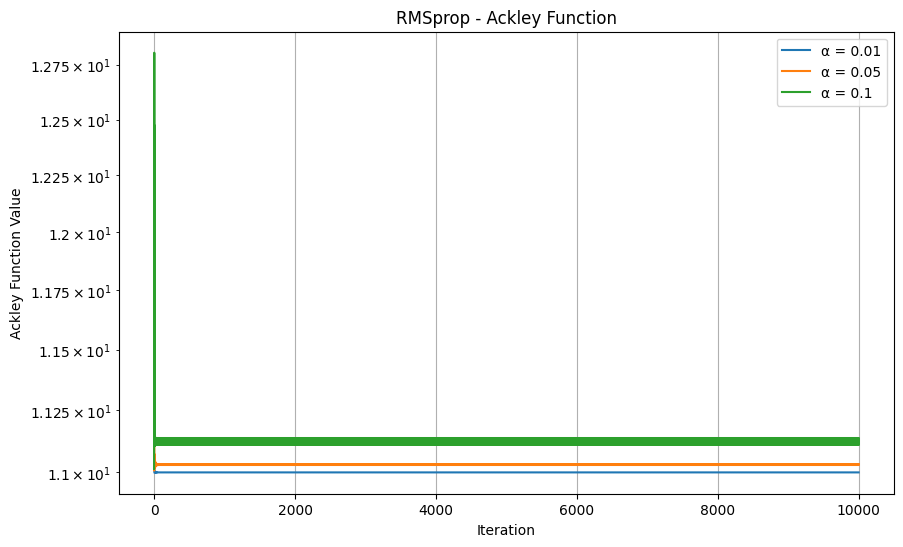

In [59]:
x0 = 4.0

learning_rates = [0.01, 0.05, 0.1]

plt.figure(figsize=(10, 6))

for alpha in learning_rates:

    start = time.perf_counter()

    x_final, history, iterations = rmsprop(
        x0, alpha
    )

    end = time.perf_counter()

    print("\nRMSprop")
    print("Learning rate:", alpha)
    print("Final x      :", x_final)
    print("Final f(x)   :", ackley(x_final))
    print("Iterations   :", iterations)
    print("Time (sec)   :", end - start)

    plt.plot(
        history,
        label=f"α = {alpha}"
    )


plt.xlabel("Iteration")
plt.ylabel("Ackley Function Value")
plt.title("RMSprop - Ackley Function")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

# Adagrad

In [60]:
def adagrad(x0, alpha,
            epsilon=1e-8,
            max_iter=10000,
            tolerance=1e-8):

    x = x0

    accumulated_gradient = 0.0

    history = []

    for i in range(max_iter):

        f = ackley(x)
        history.append(f)

        grad = gradient(x)

        if abs(grad) < tolerance:
            break

        # Accumulate squared gradients
        accumulated_gradient += grad ** 2

        # Update
        x = x - alpha * grad / (
            np.sqrt(accumulated_gradient) + epsilon
        )

    return x, history, i + 1


Adagrad
Learning rate: 0.01
Final x      : 3.9830676997838923
Final f(x)   : 10.998262102599446
Iterations   : 26
Time (sec)   : 0.0012355510007182602

Adagrad
Learning rate: 0.05
Final x      : 3.983067699761446
Final f(x)   : 10.998262102599446
Iterations   : 21
Time (sec)   : 0.0015722030002507381

Adagrad
Learning rate: 0.1
Final x      : 3.983067699633274
Final f(x)   : 10.998262102599446
Iterations   : 32
Time (sec)   : 0.0005334799989213934


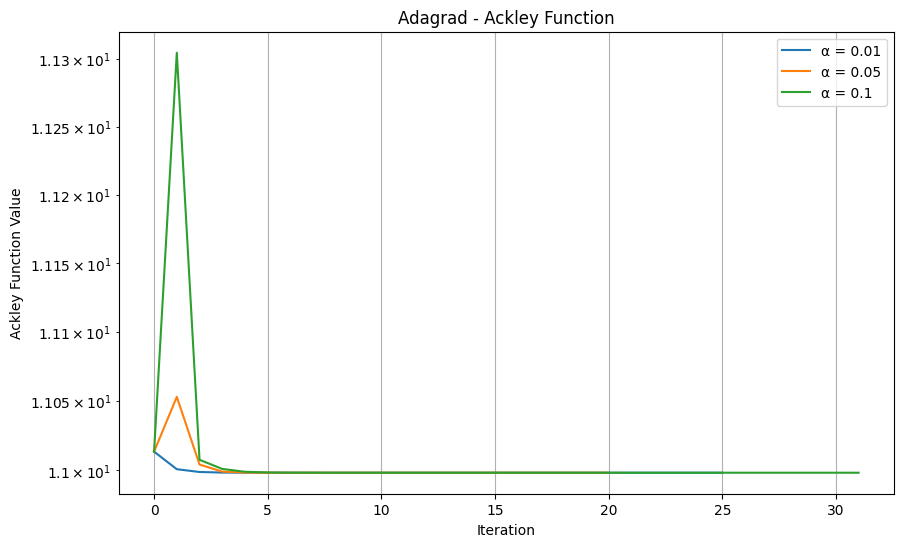

In [61]:
x0 = 4.0

learning_rates = [0.01, 0.05, 0.1]

plt.figure(figsize=(10, 6))

for alpha in learning_rates:

    start = time.perf_counter()

    x_final, history, iterations = adagrad(
        x0, alpha
    )

    end = time.perf_counter()

    print("\nAdagrad")
    print("Learning rate:", alpha)
    print("Final x      :", x_final)
    print("Final f(x)   :", ackley(x_final))
    print("Iterations   :", iterations)
    print("Time (sec)   :", end - start)

    plt.plot(
        history,
        label=f"α = {alpha}"
    )


plt.xlabel("Iteration")
plt.ylabel("Ackley Function Value")
plt.title("Adagrad - Ackley Function")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

comparisons

In [63]:


# Starting point
x0 = 4.0

# Learning rates
learning_rates = [0.01, 0.05, 0.1]

# Store all results
results = {
    "Gradient Descent": {},
    "Momentum": {},
    "Adam": {},
    "RMSprop": {},
    "Adagrad": {}
}

# --------------------------------------------------
# Run all algorithms
# --------------------------------------------------

for alpha in learning_rates:

    # Gradient Descent
    x_final, history, iterations = gradient_descent(
        x0, alpha
    )

    results["Gradient Descent"][alpha] = {
        "x": x_final,
        "history": history,
        "iterations": iterations,
        "f": ackley(x_final)
    }

    # Momentum
    x_final, history, iterations = momentum(
        x0, alpha
    )

    results["Momentum"][alpha] = {
        "x": x_final,
        "history": history,
        "iterations": iterations,
        "f": ackley(x_final)
    }

    # Adam
    x_final, history, iterations = adam(
        x0, alpha
    )

    results["Adam"][alpha] = {
        "x": x_final,
        "history": history,
        "iterations": iterations,
        "f": ackley(x_final)
    }

    # RMSprop
    x_final, history, iterations = rmsprop(
        x0, alpha
    )

    results["RMSprop"][alpha] = {
        "x": x_final,
        "history": history,
        "iterations": iterations,
        "f": ackley(x_final)
    }

    # Adagrad
    x_final, history, iterations = adagrad(
        x0, alpha
    )

    results["Adagrad"][alpha] = {
        "x": x_final,
        "history": history,
        "iterations": iterations,
        "f": ackley(x_final)
    }


In [64]:
print("=" * 80)
print("FINAL RESULTS")
print("=" * 80)

for algorithm in results:

    print(f"\n{algorithm}")
    print("-" * 60)

    for alpha in learning_rates:

        result = results[algorithm][alpha]

        print(
            f"Learning rate = {alpha:<5} | "
            f"x = {result['x']:.10f} | "
            f"f(x) = {result['f']:.10e} | "
            f"Iterations = {result['iterations']}"
        )


FINAL RESULTS

Gradient Descent
------------------------------------------------------------
Learning rate = 0.01  | x = 3.9830676997 | f(x) = 1.0998262103e+01 | Iterations = 8
Learning rate = 0.05  | x = 0.3875705115 | f(x) = 3.7426601954e+00 | Iterations = 10000
Learning rate = 0.1   | x = -1.3866561397 | f(x) = 7.0931187047e+00 | Iterations = 10000

Momentum
------------------------------------------------------------
Learning rate = 0.01  | x = 3.9830676997 | f(x) = 1.0998262103e+01 | Iterations = 318
Learning rate = 0.05  | x = -97.1161389949 | f(x) = 2.0611083525e+01 | Iterations = 10000
Learning rate = 0.1   | x = -108.9277416338 | f(x) = 2.0261887702e+01 | Iterations = 10000

Adam
------------------------------------------------------------
Learning rate = 0.01  | x = 3.9830676997 | f(x) = 1.0998262103e+01 | Iterations = 294
Learning rate = 0.05  | x = 3.9830676998 | f(x) = 1.0998262103e+01 | Iterations = 338
Learning rate = 0.1   | x = 3.9830676997 | f(x) = 1.0998262103e+01 | 

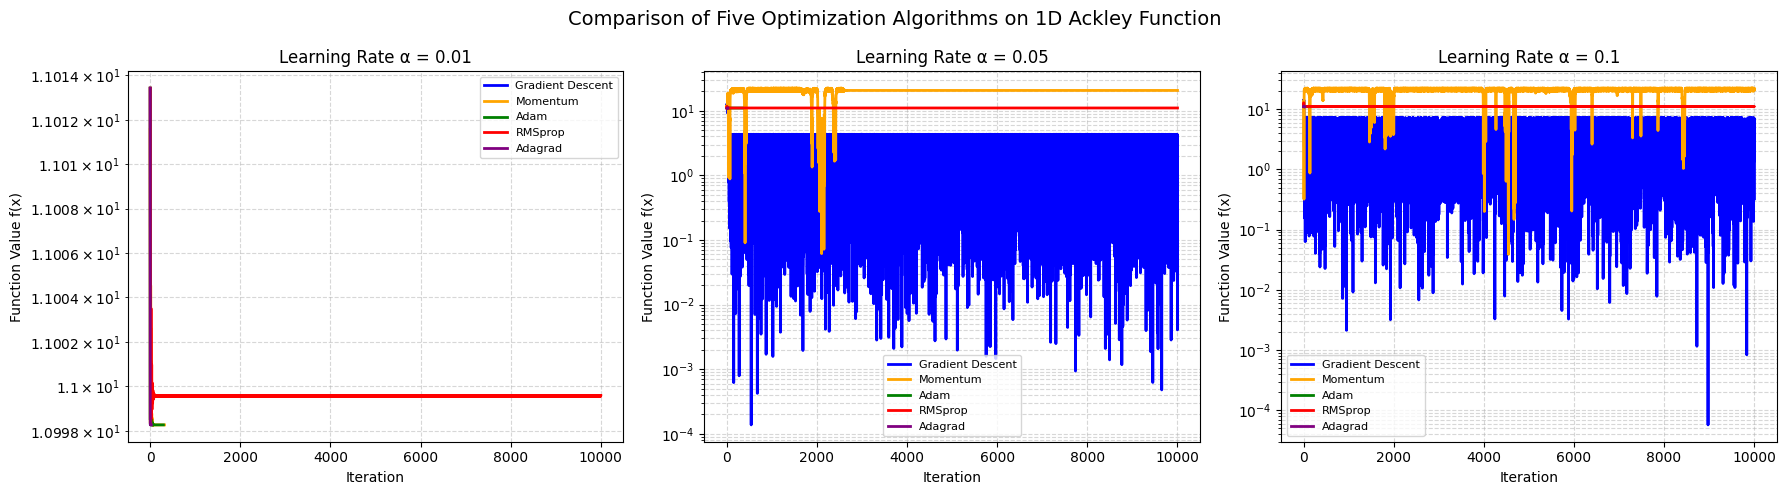

In [65]:
# ==================================================
# GRAPH 1
# Compare all 5 algorithms for each learning rate
# ==================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

colors = {
    "Gradient Descent": "blue",
    "Momentum": "orange",
    "Adam": "green",
    "RMSprop": "red",
    "Adagrad": "purple"
}

for ax, alpha in zip(axes, learning_rates):

    for algorithm in results:

        history = results[algorithm][alpha]["history"]

        # Avoid zero on log scale
        history_plot = np.maximum(history, 1e-12)

        ax.plot(
            range(1, len(history_plot) + 1),
            history_plot,
            label=algorithm,
            color=colors[algorithm],
            linewidth=2
        )

    ax.set_title(f"Learning Rate α = {alpha}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Function Value f(x)")

    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    ax.legend(fontsize=8)

plt.suptitle(
    "Comparison of Five Optimization Algorithms on 1D Ackley Function",
    fontsize=14
)

plt.tight_layout()
plt.show()


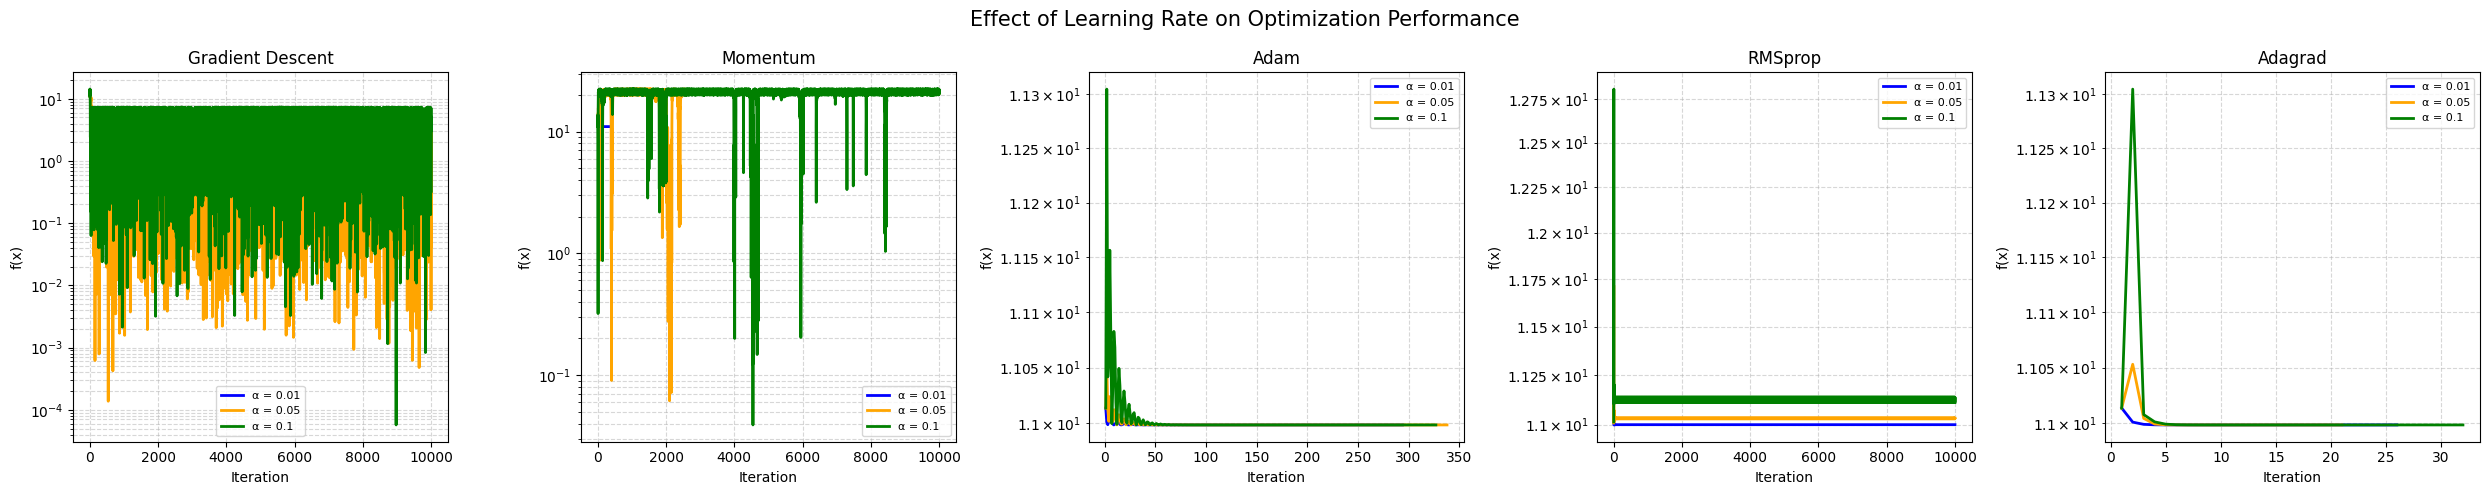

In [66]:
# ==================================================
# GRAPH 2
# Compare learning rates for each algorithm
# ==================================================

fig, axes = plt.subplots(
    1, 5,
    figsize=(25, 5)
)

lr_colors = {
    0.01: "blue",
    0.05: "orange",
    0.1: "green"
}

for ax, algorithm in zip(axes, results.keys()):

    for alpha in learning_rates:

        history = results[algorithm][alpha]["history"]

        history_plot = np.maximum(history, 1e-12)

        ax.plot(
            range(1, len(history_plot) + 1),
            history_plot,
            label=f"α = {alpha}",
            color=lr_colors[alpha],
            linewidth=2
        )

    ax.set_title(algorithm)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("f(x)")

    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    ax.legend(fontsize=8)

plt.suptitle(
    "Effect of Learning Rate on Optimization Performance",
    fontsize=15
)

plt.tight_layout()
plt.show()
